In [21]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
RANDOM_STATE = 42

TARGET_COL = "alarm_active"

DATA_PATH = "../data/final_merged_dataset.parquet"
MODEL_PATH = "../models/2__hist_gradient_boosting__v1.pkl"

In [3]:
df = pd.read_parquet(DATA_PATH)
df.head()

,city_name,datetime_hour,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipcover,day_snow,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,Vinnytsia,2022-02-24 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Vinnytsia,2022-02-24 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,Vinnytsia,2022-02-24 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,Vinnytsia,2022-02-24 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,Vinnytsia,2022-02-24 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [4]:
df.shape

(853536, 465)

In [5]:
df = df.sort_values("datetime_hour").reset_index(drop=True)

In [8]:
drop_cols = [
    TARGET_COL,
    "alarm_minutes_in_hour",
    "datetime_hour",
    "day_datetime",
    "day_sunrise",
    "day_sunset",
    "city_name",
    "region_key",
]

y = df[TARGET_COL].astype(int)

X = df.drop(columns=drop_cols, errors="ignore")
X = X.select_dtypes(include=["number", "bool"]).copy()

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(np.int8)

print("X shape:", X.shape)
print("Positive rate:", y.mean())
print("Bool cols:", len(bool_cols))

X shape: (853536, 457)
Positive rate: 0.21377657181419413
Bool cols: 4


In [9]:
n = len(X)
split_index = int(n * 0.80)

X_train = X.iloc[:split_index].copy()
y_train = y.iloc[:split_index].copy()

X_test = X.iloc[split_index:].copy()
y_test = y.iloc[split_index:].copy()

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate :", round(y_test.mean(), 4))

Train: (682828, 457) (682828,)
Test : (170708, 457) (170708,)
Train positive rate: 0.1902
Test positive rate : 0.3083


In [10]:
param_grid = [
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 0.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 400,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 100,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 500,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0,
    },
]

In [11]:
tscv = TimeSeriesSplit(n_splits=3)

best_params = None
best_cv_score = -np.inf
best_oof_proba = pd.Series(index=X_train.index, dtype=float)

for params in param_grid:
    fold_scores = []
    oof_proba = pd.Series(index=X_train.index, dtype=float)

    print("\nTesting params:", params)

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]

        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        sample_weight_tr = compute_sample_weight(
            class_weight="balanced",
            y=y_tr
        )

        model = HistGradientBoostingClassifier(
            loss="log_loss",
            random_state=RANDOM_STATE,
            early_stopping=False,
            **params
        )

        model.fit(X_tr, y_tr, sample_weight=sample_weight_tr)

        val_proba = model.predict_proba(X_val)[:, 1]
        oof_proba.iloc[val_idx] = val_proba

        fold_roc = roc_auc_score(y_val, val_proba)
        fold_ap = average_precision_score(y_val, val_proba)
        fold_scores.append(fold_roc)

        print(f"  Fold {fold}: ROC-AUC = {fold_roc:.4f} | PR-AUC = {fold_ap:.4f}")

    mean_score = float(np.mean(fold_scores))
    print(f"Mean CV ROC-AUC = {mean_score:.4f}")

    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_params = params
        best_oof_proba = oof_proba.copy()

print("\nBest params:", best_params)
print("Best CV ROC-AUC:", round(best_cv_score, 4))


Testing params: {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 50, 'l2_regularization': 0.0}
  Fold 1: ROC-AUC = 0.8602 | PR-AUC = 0.5511
  Fold 2: ROC-AUC = 0.8850 | PR-AUC = 0.6974
  Fold 3: ROC-AUC = 0.9209 | PR-AUC = 0.8051
Mean CV ROC-AUC = 0.8887

Testing params: {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': 1.0}
  Fold 1: ROC-AUC = 0.8599 | PR-AUC = 0.5538
  Fold 2: ROC-AUC = 0.8850 | PR-AUC = 0.6952
  Fold 3: ROC-AUC = 0.9213 | PR-AUC = 0.8072
Mean CV ROC-AUC = 0.8888

Testing params: {'learning_rate': 0.03, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 1.0}
  Fold 1: ROC-AUC = 0.8616 | PR-AUC = 0.5617
  Fold 2: ROC-AUC = 0.8874 | PR-AUC = 0.7018
  Fold 3: ROC-AUC = 0.9230 | PR-AUC = 0.8109
Mean CV ROC-AUC = 0.8907

Best params: {'learning_rate': 0.03, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 1.0}
Be

In [12]:
threshold_grid = np.arange(0.30, 0.71, 0.05)

valid_mask = best_oof_proba.notna()
y_oof = y_train.loc[valid_mask]
proba_oof = best_oof_proba.loc[valid_mask]

best_threshold = 0.50
best_threshold_f1 = -np.inf

for thr in threshold_grid:
    pred_oof = (proba_oof >= thr).astype(int)
    score = f1_score(y_oof, pred_oof, zero_division=0)

    print(f"threshold={thr:.2f} : OOF F1={score:.4f}")

    if score > best_threshold_f1:
        best_threshold_f1 = score
        best_threshold = float(thr)

print("\nBest threshold:", best_threshold)
print("Best OOF F1:", round(best_threshold_f1, 4))

threshold=0.30 | OOF F1=0.6051
threshold=0.35 | OOF F1=0.6260
threshold=0.40 | OOF F1=0.6451
threshold=0.45 | OOF F1=0.6609
threshold=0.50 | OOF F1=0.6740
threshold=0.55 | OOF F1=0.6842
threshold=0.60 | OOF F1=0.6895
threshold=0.65 | OOF F1=0.6908
threshold=0.70 | OOF F1=0.6873

Best threshold: 0.6499999999999999
Best OOF F1: 0.6908


In [13]:
sample_weight_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

final_model = HistGradientBoostingClassifier(
    loss="log_loss",
    random_state=RANDOM_STATE,
    early_stopping=False,
    **best_params
)

final_model.fit(X_train, y_train, sample_weight=sample_weight_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",63
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",50
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_d

In [14]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)
f1 = f1_score(y_test, test_pred, zero_division=0)
precision = precision_score(y_test, test_pred, zero_division=0)
recall = recall_score(y_test, test_pred, zero_division=0)

print("=== FINAL TEST METRICS ===")
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))
print("F1       :", round(f1, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

=== FINAL TEST METRICS ===
ROC-AUC  : 0.943
PR-AUC   : 0.8861
F1       : 0.8222
Precision: 0.7776
Recall   : 0.8722

Classification report:
              precision    recall  f1-score   support

           0     0.9398    0.8888    0.9136    118084
           1     0.7776    0.8722    0.8222     52624

    accuracy                         0.8837    170708
   macro avg     0.8587    0.8805    0.8679    170708
weighted avg     0.8898    0.8837    0.8854    170708



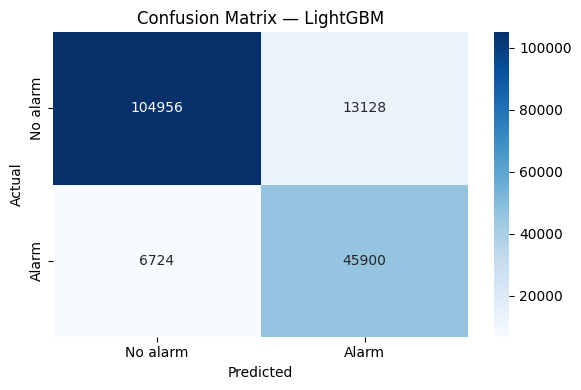

In [22]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No alarm", "Alarm"],
            yticklabels=["No alarm", "Alarm"])
plt.title("Confusion Matrix — LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [16]:
sample_size = min(20000, len(X_test))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=sample_size, replace=False)

X_perm = X_test.iloc[sample_idx].copy()
y_perm = y_test.iloc[sample_idx].copy()

perm = permutation_importance(
    estimator=final_model,
    X=X_perm,
    y=y_perm,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

top20 = importance_df.head(20).copy()
top20

,feature,importance_mean,importance_std
433,alarm_lag_1,0.287753,0.005261
437,alarms_in_last_24h,0.040002,0.001833
185,tg_topic_2,0.022525,0.001368
32,region_id,0.014357,0.001309
441,neighbour_alarms,0.011761,0.000868
27,hour,0.004694,0.000793
184,tg_topic_1,0.003772,0.000403
440,total_active_alarms_lag1,0.001684,0.000171
442,hours_since_last_alarm,0.001275,0.000475
186,tg_topic_3,0.001035,0.000101


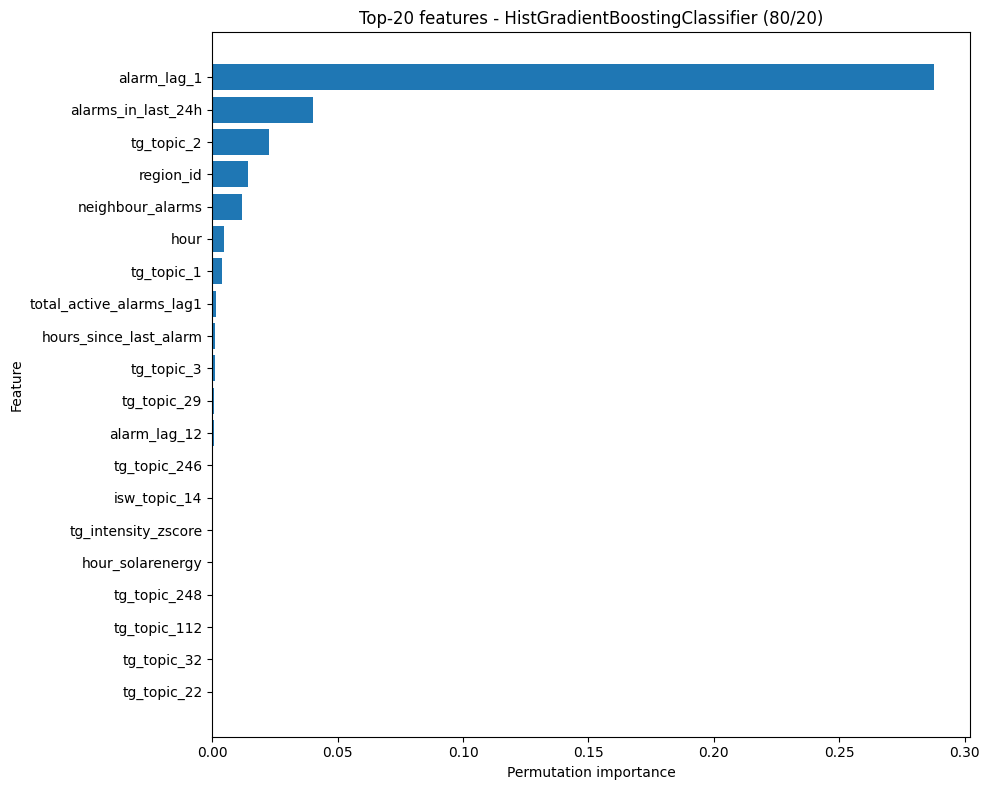

In [17]:
plt.figure(figsize=(10, 8))
plt.barh(top20["feature"][::-1], top20["importance_mean"][::-1])
plt.xlabel("Permutation importance")
plt.ylabel("Feature")
plt.title("Top-20 features - HistGradientBoostingClassifier (80/20)")
plt.tight_layout()
plt.show()